# Stage 8 — Full Pipeline: Raw Data → Rule-Based Detection → Feature Engineering → LightGBM → Residual Anomaly Scoring

Builds everything from raw CSVs. Inline Stage 1 rule-based detection, full feature engineering from scratch, 3-fold CV, LightGBM refit, residual calibration, anomaly export.

In [1]:
import gc, time, warnings
from collections import defaultdict
from pathlib import Path
import os

import holidays as holidays_lib
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import find_dotenv, load_dotenv
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
load_dotenv(find_dotenv())

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13, 'axes.labelsize': 11})

# --- Paths ---
RAW_DIR       = Path('../../data/raw/data')
ELEC_PATH     = RAW_DIR / 'meters/cleaned/electricity_cleaned.csv'
META_PATH     = RAW_DIR / 'metadata/metadata.csv'
WEATHER_PATH  = RAW_DIR / 'weather/weather.csv'
OUTPUTS_DIR   = Path('../../data/processed/anomaly-detection')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

STAGE8_ANOMALIES_OUT   = OUTPUTS_DIR / 'stage8_anomalies.parquet'
STAGE8_RESID_STATS_OUT = OUTPUTS_DIR / 'stage8_resid_stats.parquet'
STAGE8_MODEL_OUT       = OUTPUTS_DIR / 'stage8_lgbm_model.txt'

# --- Constants ---
ANOMALY_Z    = 3.0
RANDOM_STATE = 42
TEST_START   = pd.Timestamp('2017-10-01')
NO_DATA_MISSING_RATE = 0.95

MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('stage8_full_pipeline')

<Experiment: artifact_location='/mlflow/artifacts/3', creation_time=1782228938748, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1782228938748, lifecycle_stage='active', name='stage8_full_pipeline', tags={}, trace_location=None, workspace='default'>

## Section 1 — Load Raw Data

In [2]:
elec = pd.read_csv(ELEC_PATH, parse_dates=['timestamp'])
elec.sort_values('timestamp', inplace=True)
elec.reset_index(drop=True, inplace=True)
building_cols = [c for c in elec.columns if c != 'timestamp']

meta = pd.read_csv(META_PATH)
weather = pd.read_csv(WEATHER_PATH)
weather['timestamp'] = pd.to_datetime(weather['timestamp'])

print(f'Electricity shape   : {elec.shape}')
print(f'Metadata shape      : {meta.shape}')
print(f'Weather shape       : {weather.shape}')
print(f'Date range          : {elec["timestamp"].min()} \u2192 {elec["timestamp"].max()}')
print(f'Building columns    : {len(building_cols):,}')

Electricity shape   : (17544, 1579)
Metadata shape      : (1636, 32)
Weather shape       : (331166, 10)
Date range          : 2016-01-01 00:00:00 → 2017-12-31 23:00:00
Building columns    : 1,578


## Section 2 — Rule-Based Anomaly Detection (Stage 1 Logic Inline)

### 2a: Metadata mapping

In [3]:
meta_bld_set = set(meta['building_id'].dropna())
elec_bld_set = set(building_cols)
matched = elec_bld_set & meta_bld_set

meta_lookup = (
    meta[meta['building_id'].isin(building_cols)]
    .drop_duplicates('building_id')
    .set_index('building_id')
)
bld_to_site  = meta_lookup['site_id'].to_dict()
bld_to_usage = meta_lookup['primaryspaceusage'].fillna('Unknown').to_dict()
building_cols = [c for c in building_cols if c in bld_to_site]

building_missing_rate   = elec[building_cols].isna().mean()
building_non_null_count = elec[building_cols].notna().sum()
no_data_buildings = building_missing_rate[building_missing_rate > NO_DATA_MISSING_RATE].index.tolist()
detection_cols    = [c for c in building_cols if c not in set(no_data_buildings)]

print(f'Matched buildings          : {len(matched):,}')
print(f'No-data buildings (>{NO_DATA_MISSING_RATE:.0%}): {len(no_data_buildings):,}')
print(f'Detection buildings        : {len(detection_cols):,}')

Matched buildings          : 1,578
No-data buildings (>95%): 13
Detection buildings        : 1,565


In [4]:
# Build no_data_df
no_data_records = []
for bld in no_data_buildings:
    no_data_records.append({
        'building_id':        bld,
        'site_id':            bld_to_site.get(bld),
        'primaryspaceusage':  bld_to_usage.get(bld, 'Unknown'),
        'timestamp':          None,
        'start_time':         elec['timestamp'].min(),
        'end_time':           elec['timestamp'].max(),
        'duration_hours':     int(building_non_null_count.get(bld, 0)),
        'anomaly_type':       'no_data_building',
        'actual_value':       None,
        'repeated_value':     None,
        'threshold_value':    None,
        'missing_rate':       float(building_missing_rate.get(bld, 1.0)),
        'exclude_downstream': True,
        'severity':           'Critical',
        'reason':             f'Building has >{NO_DATA_MISSING_RATE:.0%} missing data',
    })
no_data_df = pd.DataFrame(no_data_records)
print(f'no_data_df shape: {no_data_df.shape}')

no_data_df shape: (13, 15)


### 2b: Severity helpers

In [5]:
ZERO_RUN_MIN_HOURS         = 2
MISSING_RUN_MIN_HOURS      = 2
DEFAULT_FLATLINE_MIN_HOURS = 12
LOOSE_FLATLINE_MIN_HOURS   = 24
NEAR_ZERO_EPSILON_KWH      = 0.01
LOOSE_FLATLINE_USAGES      = {'Lodging/residential', 'Parking'}
CRITICAL_NEAR_ZERO_USAGES  = {'Healthcare'}


def missing_run_severity(hours):
    if hours > 72:
        return 'Critical'
    elif hours > 24:
        return 'High'
    elif hours > 6:
        return 'Medium'
    return 'Low'


def zero_run_severity(hours):
    if hours > 48:
        return 'Critical'
    elif hours > 12:
        return 'High'
    elif hours > 3:
        return 'Medium'
    return 'Low'


def flatline_min_hours(primaryspaceusage, repeated_value):
    if primaryspaceusage in LOOSE_FLATLINE_USAGES:
        return LOOSE_FLATLINE_MIN_HOURS
    return DEFAULT_FLATLINE_MIN_HOURS


def flatline_severity(hours, primaryspaceusage, repeated_value):
    is_near_zero = (repeated_value is not None) and (abs(repeated_value) <= NEAR_ZERO_EPSILON_KWH)
    if is_near_zero and primaryspaceusage in CRITICAL_NEAR_ZERO_USAGES:
        return 'Critical'
    if hours > 72:
        return 'Critical'
    elif hours > 24:
        return 'High'
    elif hours > 12:
        return 'Medium'
    return 'Low'


def negative_severity(value):
    if value < -10:
        return 'High'
    return 'Medium'


def spike_severity(value, building_threshold, usage_threshold):
    if value > building_threshold and value > usage_threshold:
        return 'Critical'
    return 'High'

### 2c: Helper functions & isolated missing readings

In [6]:
def _nan_run_table(s):
    is_nan = s.isna()
    if not is_nan.any():
        return pd.DataFrame(columns=['start_time', 'end_time', 'duration_hours'])
    change = is_nan != is_nan.shift(fill_value=False)
    run_id = change.cumsum()[is_nan]
    ts_vals = pd.Series(s.index, index=s.index)[is_nan]
    df = pd.DataFrame({'ts': ts_vals.values, 'run': run_id.values})
    return df.groupby('run').agg(
        start_time=('ts', 'first'),
        end_time=('ts', 'last'),
        duration_hours=('ts', 'count'),
    ).reset_index(drop=True)


def _flatline_runs(s, min_hours=DEFAULT_FLATLINE_MIN_HOURS):
    valid = s.notna() & (s != 0)
    s_v = s[valid]
    if len(s_v) < min_hours:
        return []
    change = (s_v != s_v.shift(1)).fillna(True)
    run_id = change.cumsum()
    df = pd.DataFrame({'ts': s_v.index, 'val': s_v.values, 'run': run_id.values})
    agg = df.groupby('run').agg(
        start_time=('ts', 'first'),
        end_time=('ts', 'last'),
        duration_hours=('ts', 'count'),
        repeated_value=('val', 'first'),
    )
    return agg[agg['duration_hours'] >= min_hours].to_dict('records')


elec_idx = elec.set_index('timestamp')

# Isolated missing readings (duration_hours == 1)
missing_records = []
for bld in detection_cols:
    s = elec_idx[bld]
    runs = _nan_run_table(s)
    isolated = runs[runs['duration_hours'] == 1]
    for _, row in isolated.iterrows():
        missing_records.append({
            'building_id':        bld,
            'site_id':            bld_to_site.get(bld),
            'primaryspaceusage':  bld_to_usage.get(bld, 'Unknown'),
            'timestamp':          row['start_time'],
            'start_time':         row['start_time'],
            'end_time':           row['end_time'],
            'duration_hours':     int(row['duration_hours']),
            'anomaly_type':       'isolated_missing',
            'actual_value':       None,
            'repeated_value':     None,
            'threshold_value':    None,
            'missing_rate':       None,
            'exclude_downstream': False,
            'severity':           'Low',
            'reason':             'Single missing reading',
        })
missing_df = pd.DataFrame(missing_records)
print(f'Isolated missing records: {len(missing_df):,}')

Isolated missing records: 23,631


### 2d: Long missing runs (≥2h)

In [7]:
long_missing_records = []
for bld in detection_cols:
    s = elec_idx[bld]
    runs = _nan_run_table(s)
    long_runs = runs[runs['duration_hours'] >= MISSING_RUN_MIN_HOURS]
    for _, row in long_runs.iterrows():
        long_missing_records.append({
            'building_id':        bld,
            'site_id':            bld_to_site.get(bld),
            'primaryspaceusage':  bld_to_usage.get(bld, 'Unknown'),
            'timestamp':          row['start_time'],
            'start_time':         row['start_time'],
            'end_time':           row['end_time'],
            'duration_hours':     int(row['duration_hours']),
            'anomaly_type':       'long_missing_run',
            'actual_value':       None,
            'repeated_value':     None,
            'threshold_value':    None,
            'missing_rate':       None,
            'exclude_downstream': False,
            'severity':           missing_run_severity(int(row['duration_hours'])),
            'reason':             f"Missing run of {int(row['duration_hours'])}h",
        })
long_missing_df = pd.DataFrame(long_missing_records)
print(f'Long missing run records: {len(long_missing_df):,}')

Long missing run records: 23,712


### 2e: Flatline & near-zero flatline runs

In [8]:
flatline_records = []
for bld in detection_cols:
    usage = bld_to_usage.get(bld, 'Unknown')
    s = elec_idx[bld]
    min_h = flatline_min_hours(usage, None)
    runs = _flatline_runs(s, min_hours=min_h)
    for run in runs:
        rv = run['repeated_value']
        is_near_zero = abs(rv) <= NEAR_ZERO_EPSILON_KWH
        a_type = 'near_zero_flatline' if is_near_zero else 'flatline'
        sev = flatline_severity(run['duration_hours'], usage, rv)
        flatline_records.append({
            'building_id':        bld,
            'site_id':            bld_to_site.get(bld),
            'primaryspaceusage':  usage,
            'timestamp':          run['start_time'],
            'start_time':         run['start_time'],
            'end_time':           run['end_time'],
            'duration_hours':     int(run['duration_hours']),
            'anomaly_type':       a_type,
            'actual_value':       float(rv),
            'repeated_value':     float(rv),
            'threshold_value':    None,
            'missing_rate':       None,
            'exclude_downstream': False,
            'severity':           sev,
            'reason':             f"{a_type.replace('_', ' ').title()} of {int(run['duration_hours'])}h (value={rv:.4f})",
        })
flatline_df = pd.DataFrame(flatline_records)
print(f'Flatline records: {len(flatline_df):,}')

Flatline records: 46,871


### 2f: Spike / extreme readings

In [9]:
SPIKE_BUILDING_P99_MULTIPLIER = 5
SPIKE_GLOBAL_QUANTILE         = 0.999

# Per-building p99
bld_p99 = elec_idx[detection_cols].quantile(0.99)

# Per-usage p99.9
usage_p999 = {}
for usage_type in set(bld_to_usage.values()):
    usages_blds = [b for b in detection_cols if bld_to_usage.get(b) == usage_type]
    if usages_blds:
        vals = elec_idx[usages_blds].values.flatten()
        vals = vals[~np.isnan(vals)]
        if len(vals) > 0:
            usage_p999[usage_type] = float(np.quantile(vals, SPIKE_GLOBAL_QUANTILE))

spike_records = []
for bld in detection_cols:
    usage     = bld_to_usage.get(bld, 'Unknown')
    bld_thresh = float(bld_p99.get(bld, np.nan)) * SPIKE_BUILDING_P99_MULTIPLIER
    use_thresh = usage_p999.get(usage, np.nan)
    if np.isnan(bld_thresh) or np.isnan(use_thresh):
        continue
    s = elec_idx[bld].dropna()
    spike_ts = s[(s > bld_thresh) & (s > use_thresh)]
    for ts, val in spike_ts.items():
        spike_records.append({
            'building_id':        bld,
            'site_id':            bld_to_site.get(bld),
            'primaryspaceusage':  usage,
            'timestamp':          ts,
            'start_time':         ts,
            'end_time':           ts,
            'duration_hours':     1,
            'anomaly_type':       'spike',
            'actual_value':       float(val),
            'repeated_value':     None,
            'threshold_value':    float(min(bld_thresh, use_thresh)),
            'missing_rate':       None,
            'exclude_downstream': False,
            'severity':           spike_severity(val, bld_thresh, use_thresh),
            'reason':             f'Spike {val:.2f} > bld_thresh {bld_thresh:.2f} & use_thresh {use_thresh:.2f}',
        })
spike_df = pd.DataFrame(spike_records)
print(f'Spike records: {len(spike_df):,}')

Spike records: 227


### 2g: Combine all anomaly records

In [10]:
ANOMALY_COLS = [
    'anomaly_id', 'building_id', 'site_id', 'primaryspaceusage',
    'timestamp', 'start_time', 'end_time', 'duration_hours',
    'anomaly_type', 'actual_value', 'repeated_value', 'threshold_value',
    'missing_rate', 'exclude_downstream', 'severity', 'reason',
]
SEV_ORDER = pd.CategoricalDtype(['Low', 'Medium', 'High', 'Critical'], ordered=True)


def _pad_cols(df, cols):
    for col in cols:
        if col not in df.columns:
            df[col] = None
    return df[cols]


frames_to_combine = [no_data_df, missing_df, long_missing_df, flatline_df]
if len(spike_df) > 0:
    frames_to_combine.append(spike_df)

combined = pd.concat(
    [_pad_cols(f.copy(), [c for c in ANOMALY_COLS if c != 'anomaly_id']) for f in frames_to_combine],
    ignore_index=True
)
combined.insert(0, 'anomaly_id', range(len(combined)))
combined['severity'] = combined['severity'].astype(SEV_ORDER)
anomalies_df = combined.copy()

print(f'Total anomaly records : {len(anomalies_df):,}')
print('\nBy type:')
print(anomalies_df['anomaly_type'].value_counts().to_string())
print('\nBy severity:')
print(anomalies_df['severity'].value_counts().to_string())

Total anomaly records : 94,454

By type:
anomaly_type
flatline              46508
long_missing_run      23712
isolated_missing      23631
near_zero_flatline      363
spike                   227
no_data_building         13

By severity:
severity
Medium      48995
Low         37036
High         5179
Critical     3244


### 2h: Summary visualisations

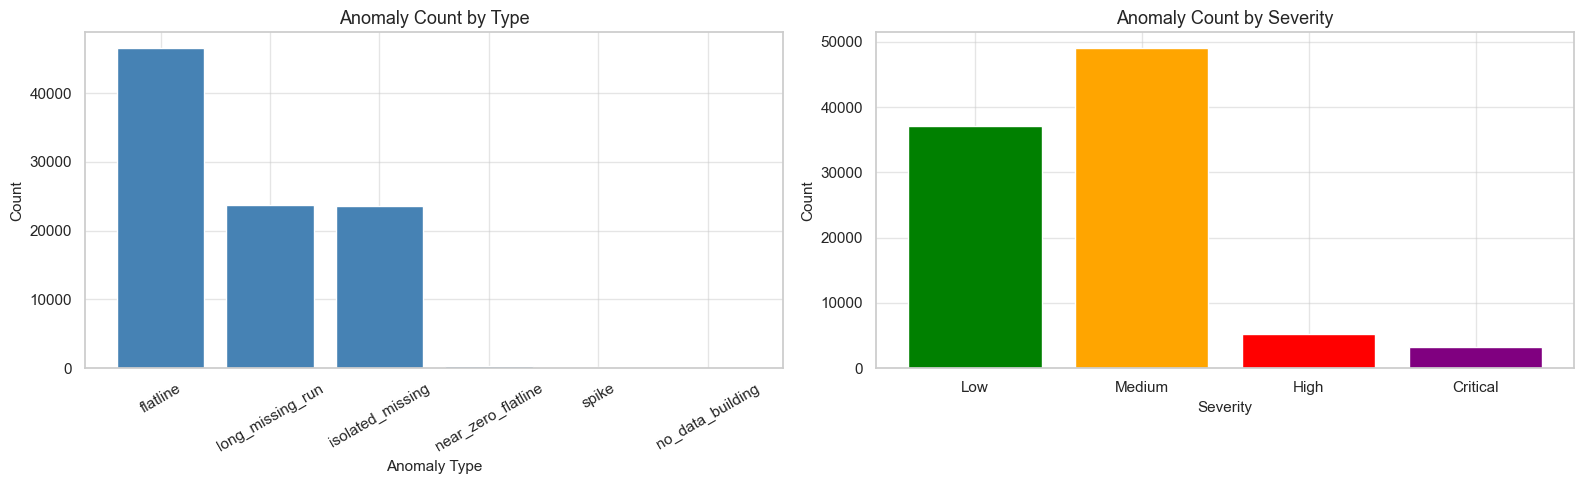

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_counts = anomalies_df['anomaly_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='steelblue')
axes[0].set_title('Anomaly Count by Type')
axes[0].set_xlabel('Anomaly Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

sev_colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red', 'Critical': 'purple'}
sev_order_list = ['Low', 'Medium', 'High', 'Critical']
sev_counts = anomalies_df['severity'].value_counts().reindex(sev_order_list).fillna(0)
axes[1].bar(sev_counts.index, sev_counts.values,
            color=[sev_colors.get(s, 'grey') for s in sev_counts.index])
axes[1].set_title('Anomaly Count by Severity')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

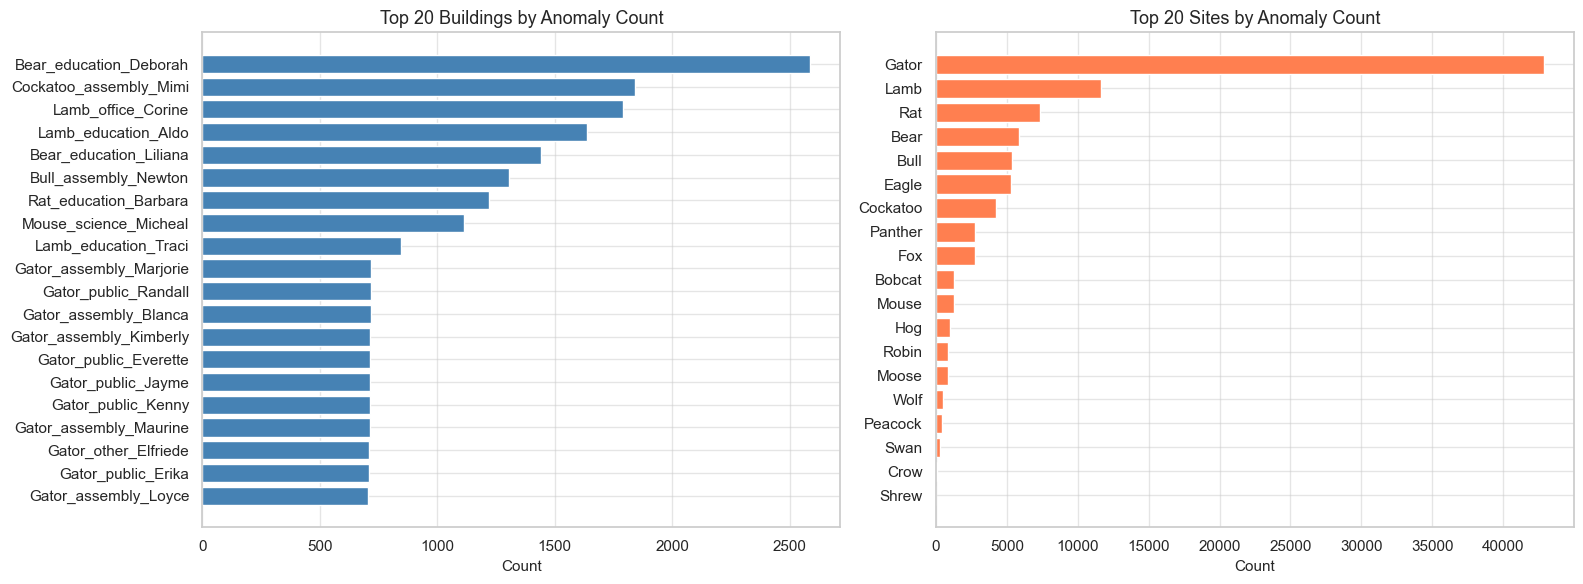

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20_bld = (
    anomalies_df.groupby('building_id').size()
    .sort_values(ascending=True).tail(20)
)
axes[0].barh(top20_bld.index, top20_bld.values, color='steelblue')
axes[0].set_title('Top 20 Buildings by Anomaly Count')
axes[0].set_xlabel('Count')

top20_site = (
    anomalies_df.groupby('site_id').size()
    .sort_values(ascending=True).tail(20)
)
axes[1].barh(top20_site.index.astype(str), top20_site.values, color='coral')
axes[1].set_title('Top 20 Sites by Anomaly Count')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

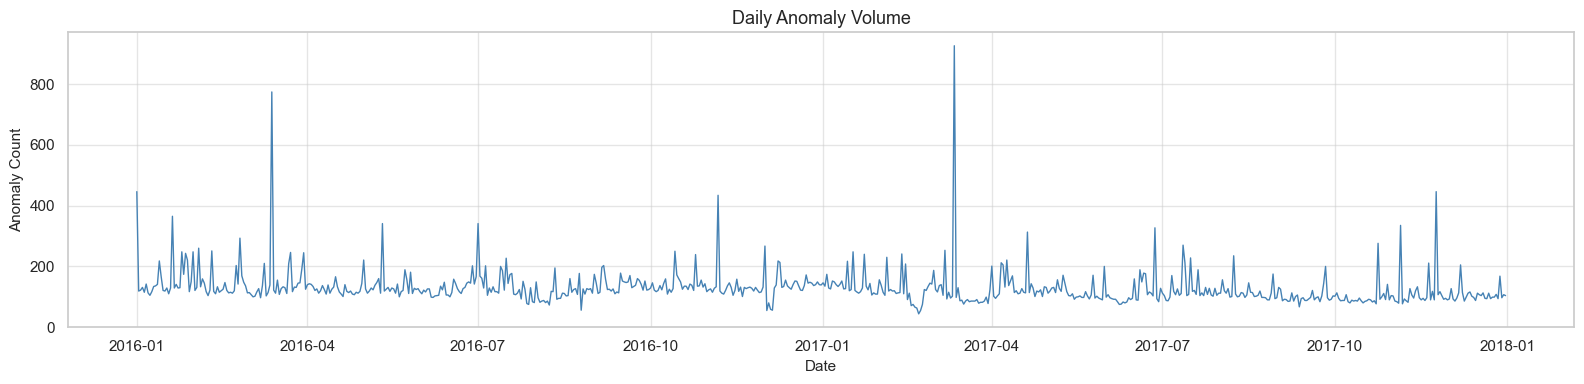

In [13]:
daily_vol = (
    anomalies_df.dropna(subset=['timestamp'])
    .assign(date=lambda d: pd.to_datetime(d['timestamp']).dt.normalize())
    .groupby('date').size()
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily_vol.index, daily_vol.values, color='steelblue', linewidth=1.0)
ax.set_title('Daily Anomaly Volume')
ax.set_xlabel('Date')
ax.set_ylabel('Anomaly Count')
plt.tight_layout()
plt.show()

## Section 3 — Feature Engineering

### 3a: Apply quality mask

In [14]:
# Build spike lookup: {building_id: set of timestamps}
spike_lookup = defaultdict(set)
if len(spike_df) > 0:
    for _, row in spike_df[['building_id', 'timestamp']].iterrows():
        spike_lookup[row['building_id']].add(row['timestamp'])

# Build near-zero flatline lookup: {building_id: set of timestamps}
nzf_lookup = defaultdict(set)
if len(flatline_df) > 0:
    nzf_df = flatline_df[flatline_df['anomaly_type'] == 'near_zero_flatline'].copy()
    for _, row in nzf_df.iterrows():
        ts_range = pd.date_range(row['start_time'], row['end_time'], freq='h')
        nzf_lookup[row['building_id']].update(ts_range)

no_data_set = set(no_data_buildings)

elec_masked = elec.copy()
valid_building_cols = [c for c in building_cols if c in elec_masked.columns]

for col in valid_building_cols:
    if col in no_data_set:
        elec_masked[col] = np.nan
        continue
    if col in nzf_lookup:
        nzf_rows = elec_masked['timestamp'].isin(nzf_lookup[col])
        elec_masked.loc[nzf_rows, col] = np.nan
    if col in spike_lookup:
        spike_rows = elec_masked['timestamp'].isin(spike_lookup[col])
        elec_masked.loc[spike_rows, col] = np.nan

print('Quality mask applied.')

Quality mask applied.


### 3b: Melt wide → long format

In [15]:
df_long = elec_masked.melt(
    id_vars='timestamp',
    value_vars=[c for c in elec_masked.columns if c != 'timestamp'],
    var_name='building_id',
    value_name='consumption',
)
df_long.sort_values(['building_id', 'timestamp'], inplace=True)
df_long.reset_index(drop=True, inplace=True)
print(f'Long format rows: {len(df_long):,}')

Long format rows: 27,684,432


### 3c: Merge metadata

In [16]:
meta_cols = meta[['building_id', 'site_id', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'timezone']].drop_duplicates('building_id')
meta_cols = meta_cols.copy()
meta_cols['sub_primaryspaceusage'] = meta_cols['sub_primaryspaceusage'].astype(str).str.strip()
meta_cols['sub_primaryspaceusage'] = meta_cols['sub_primaryspaceusage'].replace({'nan': None, '': None})

df_long = df_long.merge(meta_cols, on='building_id', how='left')

null_mask = df_long['sub_primaryspaceusage'].isna()
df_long.loc[null_mask, 'sub_primaryspaceusage'] = df_long.loc[null_mask, 'primaryspaceusage']

print(f'sub_primaryspaceusage nulls after fallback: {df_long["sub_primaryspaceusage"].isna().sum():,}')

sub_primaryspaceusage nulls after fallback: 333,336


### 3d: Calendar integers

In [17]:
df_long['hour']        = df_long['timestamp'].dt.hour.astype('int32')
df_long['day_of_week'] = df_long['timestamp'].dt.dayofweek.astype('int32')
df_long['day_of_year'] = df_long['timestamp'].dt.dayofyear.astype('int32')
df_long['week_of_year'] = df_long['timestamp'].dt.isocalendar().week.astype('int32')
df_long['is_weekend']  = (df_long['day_of_week'] > 5).astype('int8')

### 3f: Lag features

In [18]:
grp = df_long.groupby('building_id', sort=False)['consumption']
df_long['lag_1h']   = grp.transform(lambda s: s.shift(1)).astype('float32')
df_long['lag_24h']  = grp.transform(lambda s: s.shift(24)).astype('float32')
df_long['lag_168h'] = grp.transform(lambda s: s.shift(168)).astype('float32')
print('Lag features computed.')

Lag features computed.


### 3g: Rolling statistics (shift(1) to avoid leakage)

In [19]:
grp = df_long.groupby('building_id', sort=False)['consumption']
for window, suffix in [(6, '6h'), (24, '24h'), (168, '168h')]:
    df_long[f'rolling_mean_{suffix}'] = (
        grp.transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
        .astype('float32')
    )
    df_long[f'rolling_std_{suffix}'] = (
        grp.transform(lambda s: s.shift(1).rolling(window, min_periods=2).std())
        .astype('float32')
    )
print('Rolling statistics computed.')

Rolling statistics computed.


### 3h: Historical baseline (expanding + shift(1))

In [20]:
df_long.sort_values(['building_id', 'timestamp'], inplace=True)
df_long.reset_index(drop=True, inplace=True)

bld_hour_grp = df_long.groupby(['building_id', 'hour'], sort=False)['consumption']
df_long['historical_hour_median'] = (
    bld_hour_grp.transform(lambda s: s.shift(1).expanding().median())
    .astype('float32')
)
df_long['historical_hour_std'] = (
    bld_hour_grp.transform(lambda s: s.shift(1).expanding().std())
    .astype('float32')
)

# Use is_weekend as daytype proxy (is_holiday added in 3j)
bld_hour_daytype_grp = df_long.groupby(['building_id', 'hour', 'is_weekend'], sort=False)['consumption']
df_long['historical_hour_daytype_median'] = (
    bld_hour_daytype_grp.transform(lambda s: s.shift(1).expanding().median())
    .astype('float32')
)
print('Historical baselines computed.')

Historical baselines computed.


### 3i: Weather join (site-level)

In [21]:
for col in ['airTemperature', 'dewTemperature', 'windSpeed']:
    if col in weather.columns:
        weather[col] = pd.to_numeric(weather[col], errors='coerce')

if {'airTemperature', 'dewTemperature'}.issubset(weather.columns):
    weather['temp_dew_spread'] = weather['airTemperature'] - weather['dewTemperature']

weather.sort_values(['site_id', 'timestamp'], inplace=True)
grp_w = weather.groupby('site_id', sort=False)['airTemperature']
weather['airTemperature_rolling_24h']  = grp_w.transform(lambda s: s.rolling(24,  min_periods=1).mean())
weather['airTemperature_rolling_168h'] = grp_w.transform(lambda s: s.rolling(168, min_periods=1).mean())

WEATHER_FEATURES = [c for c in ['airTemperature', 'windSpeed', 'temp_dew_spread',
                                  'airTemperature_rolling_24h', 'airTemperature_rolling_168h']
                    if c in weather.columns]

df_long = df_long.merge(
    weather[['timestamp', 'site_id'] + WEATHER_FEATURES],
    on=['timestamp', 'site_id'], how='left'
)
for wf in WEATHER_FEATURES:
    df_long[wf] = df_long[wf].astype('float32')
print(f'Weather features added: {WEATHER_FEATURES}')

Weather features added: ['airTemperature', 'windSpeed', 'temp_dew_spread', 'airTemperature_rolling_24h', 'airTemperature_rolling_168h']


### 3j: Holiday features

In [22]:
TIMEZONE_TO_COUNTRY = {
    'US/Pacific':    'US', 'US/Mountain': 'US',
    'US/Central':    'US', 'US/Eastern':  'US',
    'Europe/London': 'GB', 'Europe/Dublin': 'IE',
}
HOLIDAY_MAX_DAYS = 3


def build_holiday_lookup(df, years):
    site_tz = df[['site_id', 'timezone']].drop_duplicates().set_index('site_id')['timezone'].to_dict()
    records = []
    for site, tz in site_tz.items():
        country = TIMEZONE_TO_COUNTRY.get(tz)
        if country is None:
            continue
        cal = holidays_lib.country_holidays(country, years=years)
        for date in cal.keys():
            records.append({'site_id': site, 'date': pd.Timestamp(date)})
    return pd.DataFrame(records) if records else pd.DataFrame(columns=['site_id', 'date'])


def add_holiday_features(df, holiday_lookup, max_days=HOLIDAY_MAX_DAYS):
    base = pd.DataFrame({'site_id': df['site_id'].values, 'date': df['timestamp'].dt.normalize().values})
    hl = holiday_lookup.assign(is_holiday=np.int8(1))
    df['is_holiday'] = base.merge(hl, on=['site_id', 'date'], how='left')['is_holiday'].fillna(0).astype('int8').values
    days_to   = np.full(len(df), max_days, dtype='int8')
    days_from = np.full(len(df), max_days, dtype='int8')
    for d in range(max_days, 0, -1):
        sb = holiday_lookup[['site_id', 'date']].copy()
        sb['date'] -= pd.Timedelta(days=d)
        sb = sb.drop_duplicates().assign(v=np.int8(1))
        days_to[base.merge(sb, on=['site_id', 'date'], how='left')['v'].notna().values] = d
        sf = holiday_lookup[['site_id', 'date']].copy()
        sf['date'] += pd.Timedelta(days=d)
        sf = sf.drop_duplicates().assign(v=np.int8(1))
        days_from[base.merge(sf, on=['site_id', 'date'], how='left')['v'].notna().values] = d
    df['days_to_next_holiday']   = days_to
    df['days_from_last_holiday'] = days_from


holiday_lookup = build_holiday_lookup(df_long, years=[2016, 2017])
add_holiday_features(df_long, holiday_lookup)
print(f"is_holiday: {df_long['is_holiday'].sum():,} ({df_long['is_holiday'].mean()*100:.1f}%)")

is_holiday: 820,512 (3.0%)


### 3k: Drop rows with consumption = NaN → df_clean

In [23]:
df_clean = df_long.dropna(subset=['consumption']).copy()
print(f'Rows before drop : {len(df_long):,}')
print(f'Rows after drop  : {len(df_clean):,}')
print(f'Buildings        : {df_clean["building_id"].nunique():,}')
del df_long, elec_masked
gc.collect()

Rows before drop : 27,684,432
Rows after drop  : 24,658,148
Buildings        : 1,565


27

## Section 4 — Feature Selection & Leakage Audit

In [24]:
CAT_FEATURES = ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage']

FEATURE_COLS = [
    # Calendar integers
    'hour', 'day_of_week', 'day_of_year', 'week_of_year', 'is_weekend',
    # Lag
    'lag_1h', 'lag_24h', 'lag_168h',
    # Rolling mean
    'rolling_mean_6h', 'rolling_mean_24h', 'rolling_mean_168h',
    # Rolling std
    'rolling_std_6h', 'rolling_std_24h', 'rolling_std_168h',
    # Weather
    'airTemperature', 'windSpeed', 'temp_dew_spread',
    'airTemperature_rolling_24h', 'airTemperature_rolling_168h',
    # Historical baseline
    'historical_hour_median', 'historical_hour_std', 'historical_hour_daytype_median',
    # Holiday
    'is_holiday',
    # 'days_to_next_holiday', 'days_from_last_holiday',
    # Numeric metadata
    'sqm',
    # Categorical metadata
    'site_id', 'primaryspaceusage', 'sub_primaryspaceusage',
]

# Keep only columns that exist in df_clean
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_clean.columns]
# Deduplicate while preserving order
seen = set()
FEATURE_COLS_DEDUPED = []
for c in FEATURE_COLS:
    if c not in seen:
        FEATURE_COLS_DEDUPED.append(c)
        seen.add(c)
FEATURE_COLS = FEATURE_COLS_DEDUPED

CAT_PRESENT = [c for c in CAT_FEATURES if c in FEATURE_COLS]

for col in CAT_PRESENT:
    df_clean[col] = df_clean[col].astype('category')

int64_cols   = df_clean[FEATURE_COLS].select_dtypes(include=['int64']).columns.tolist()
float64_cols = df_clean[FEATURE_COLS].select_dtypes(include=['float64']).columns.tolist()
df_clean[int64_cols]   = df_clean[int64_cols].astype('int32')
df_clean[float64_cols] = df_clean[float64_cols].astype('float32')

print(f'Feature count: {len(FEATURE_COLS)}')
print(f'Categorical  : {CAT_PRESENT}')

missing_rates = df_clean[FEATURE_COLS].isna().mean().sort_values(ascending=False)
display(missing_rates.rename('missing_rate').to_frame().head(15))

Feature count: 27
Categorical  : ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage']


,missing_rate
lag_168h,0.024940
lag_24h,0.009103
sub_primaryspaceusage,0.006454
primaryspaceusage,0.006454
windSpeed,0.005320
temp_dew_spread,0.004134
airTemperature,0.003749
airTemperature_rolling_24h,0.003410
airTemperature_rolling_168h,0.003410
historical_hour_std,0.003046


## Section 5 — Time-Aware Fold Definitions

3 chronological expanding-window folds:

| Fold | Train start | Train end | Val start | Val end |
|------|-------------|-----------|-----------|--------|
| 1 | 2016-01-01 | 2016-12-31 | 2017-01-01 | 2017-03-31 |
| 2 | 2016-01-01 | 2017-03-31 | 2017-04-01 | 2017-06-30 |
| 3 | 2016-01-01 | 2017-06-30 | 2017-07-01 | 2017-09-30 |

Test (held-out): 2017-10-01 → 2017-12-31

In [25]:
FOLDS = [
    {'fold': 1, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2016-12-31 23:00:00'),
     'val_start': pd.Timestamp('2017-01-01'), 'val_end': pd.Timestamp('2017-03-31 23:00:00')},
    {'fold': 2, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-03-31 23:00:00'),
     'val_start': pd.Timestamp('2017-04-01'), 'val_end': pd.Timestamp('2017-06-30 23:00:00')},
    {'fold': 3, 'train_start': pd.Timestamp('2016-01-01'), 'train_end': pd.Timestamp('2017-06-30 23:00:00'),
     'val_start': pd.Timestamp('2017-07-01'), 'val_end': pd.Timestamp('2017-09-30 23:00:00')},
]

TARGET_COL = 'consumption'


def split_by_dates(frame, train_start, train_end, val_start, val_end):
    train_mask = (frame['timestamp'] >= train_start) & (frame['timestamp'] <= train_end)
    val_mask   = (frame['timestamp'] >= val_start)   & (frame['timestamp'] <= val_end)
    return frame.loc[train_mask].copy(), frame.loc[val_mask].copy()


dataset_cols = ['timestamp', 'building_id', TARGET_COL] + FEATURE_COLS
selected_dataset = df_clean[dataset_cols].copy()
del df_clean
gc.collect()

fold_summary = []
for fold in FOLDS:
    tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
    fold_summary.append({'fold': fold['fold'], 'train_rows': len(tr), 'val_rows': len(va)})
display(pd.DataFrame(fold_summary))

,fold,train_rows,val_rows
0,1,12413092,3050474
1,2,15463566,3026032
2,3,18489598,3101468


## Section 6 — LightGBM Training on 3 Folds

In [26]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


BASE_LGB_PARAMS = {
    'objective':         'regression',
    'metric':            'rmse',
    'boosting_type':     'gbdt',
    'n_estimators':      5000,
    'n_jobs':            12,
    'random_state':      RANDOM_STATE,
    'verbose':           -1,
    'learning_rate':     0.04,
    'num_leaves':        511,
    'max_depth':         8,
    'min_child_samples': 1500,
    'subsample':         0.85,
    'subsample_freq':    1,
    'colsample_bytree':  0.85,
    'reg_alpha':         2.0,
    'reg_lambda':        3.0,
}

EARLY_STOPPING_ROUNDS = 200


def train_eval_lgbm(train_frame, val_frame, params):
    model = lgb.LGBMRegressor(**params)
    model.fit(
        train_frame[FEATURE_COLS], train_frame[TARGET_COL],
        eval_set=[(val_frame[FEATURE_COLS], val_frame[TARGET_COL])],
        eval_metric='rmse',
        categorical_feature=CAT_PRESENT,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
            lgb.log_evaluation(250),
        ],
    )
    pred = model.predict(val_frame[FEATURE_COLS]).clip(min=0)
    return model, {
        'rmse':           rmse(val_frame[TARGET_COL], pred),
        'mae':            mean_absolute_error(val_frame[TARGET_COL], pred),
        'best_iteration': model.best_iteration_,
    }


def plot_fold_learning_curve(model, fold_num):
    val_rmse  = model.evals_result_['valid_0']['rmse']
    rounds    = range(1, len(val_rmse) + 1)
    best_iter = model.best_iteration_
    zoom_start = 200

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Fold {fold_num} \u2014 Learning Curve', fontsize=13)

    axes[0].plot(rounds, val_rmse, color='steelblue', linewidth=0.8, label='Val RMSE')
    axes[0].axvline(best_iter, color='red', linestyle='--', linewidth=1.5, label=f'Best iter {best_iter}')
    axes[0].set_title('Full run')
    axes[0].set_xlabel('Boosting round')
    axes[0].set_ylabel('Validation RMSE (kWh)')
    axes[0].legend()

    axes[1].plot(list(rounds)[zoom_start:], val_rmse[zoom_start:], color='steelblue', linewidth=1.0)
    axes[1].axvline(best_iter, color='red', linestyle='--', linewidth=1.5, label=f'Best iter {best_iter}')
    axes[1].set_title(f'Round {zoom_start+1} \u2192 {len(val_rmse)} (convergence zoom)')
    axes[1].set_xlabel('Boosting round')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print(f'  Best iter {best_iter}  |  Best val RMSE {val_rmse[best_iter-1]:.4f}  |  Final val RMSE {val_rmse[-1]:.4f}')

Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 23.3794
[500]	valid_0's rmse: 22.6069
[750]	valid_0's rmse: 22.2812
[1000]	valid_0's rmse: 22.0648
[1250]	valid_0's rmse: 21.9767
[1500]	valid_0's rmse: 21.9343
Early stopping, best iteration is:
[1492]	valid_0's rmse: 21.9234
Evaluated only: rmse
🏃 View run fold_1 at: http://localhost:5000/#/experiments/3/runs/e5372cb7e6634a26ba4b3bd060966e6d
🧪 View experiment at: http://localhost:5000/#/experiments/3

Fold 1  RMSE=21.921  MAE=6.506  best_iter=1492  time=344s


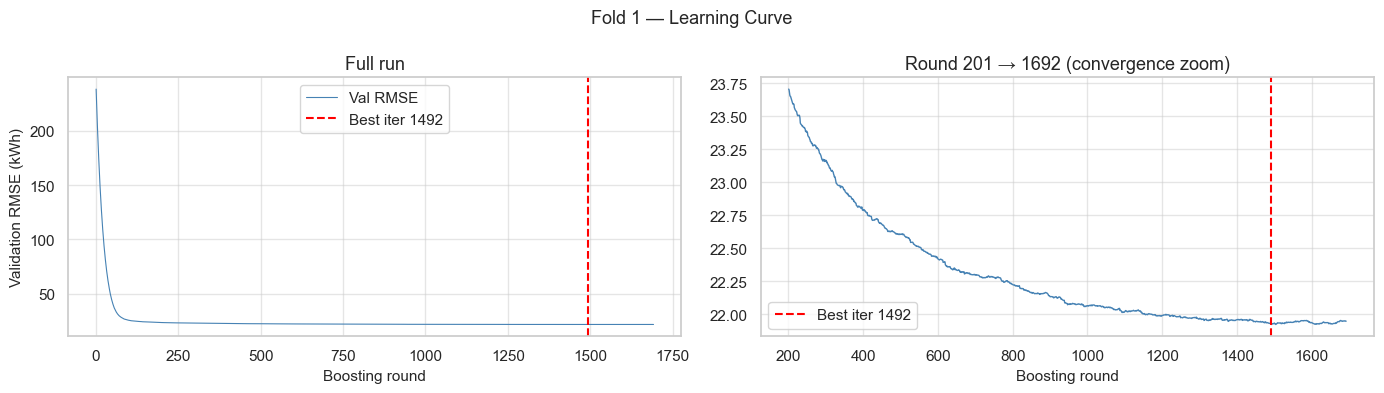

  Best iter 1492  |  Best val RMSE 21.9234  |  Final val RMSE 21.9486
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 29.2192
[500]	valid_0's rmse: 27.9839
[750]	valid_0's rmse: 27.5825
[1000]	valid_0's rmse: 27.3231
[1250]	valid_0's rmse: 27.2065
[1500]	valid_0's rmse: 27.1284
[1750]	valid_0's rmse: 27.0492
[2000]	valid_0's rmse: 26.9841
[2250]	valid_0's rmse: 26.9307
[2500]	valid_0's rmse: 26.8966
[2750]	valid_0's rmse: 26.8604
[3000]	valid_0's rmse: 26.8412
Early stopping, best iteration is:
[3024]	valid_0's rmse: 26.8364
Evaluated only: rmse
🏃 View run fold_2 at: http://localhost:5000/#/experiments/3/runs/93a448dc61754c0299b28d34b43bcc93
🧪 View experiment at: http://localhost:5000/#/experiments/3

Fold 2  RMSE=26.832  MAE=6.955  best_iter=3024  time=699s


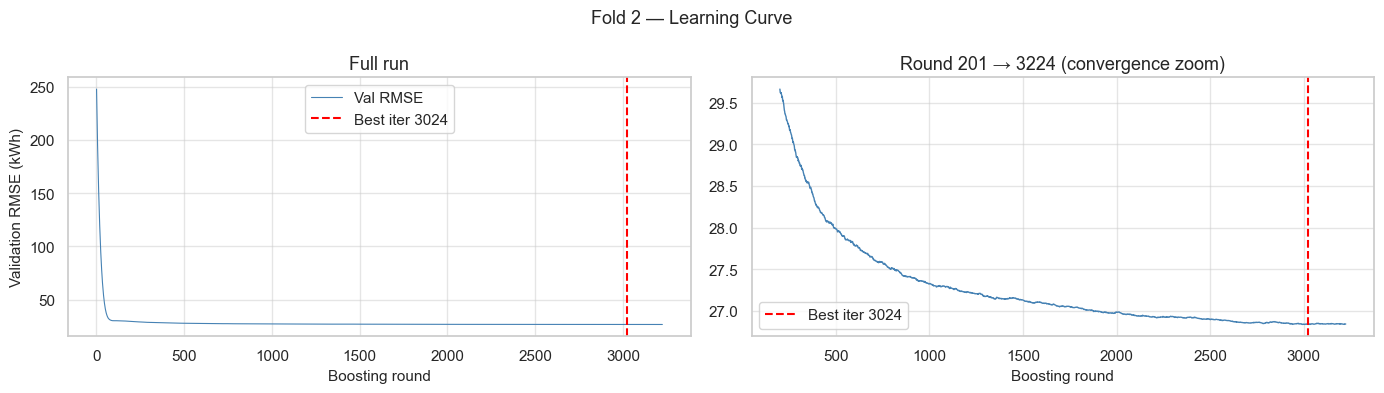

  Best iter 3024  |  Best val RMSE 26.8364  |  Final val RMSE 26.8422
Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 34.8819
[500]	valid_0's rmse: 34.0852
[750]	valid_0's rmse: 33.7764
[1000]	valid_0's rmse: 33.6409
[1250]	valid_0's rmse: 33.4944
[1500]	valid_0's rmse: 33.4056
[1750]	valid_0's rmse: 33.3285
[2000]	valid_0's rmse: 33.2878
[2250]	valid_0's rmse: 33.2806
Early stopping, best iteration is:
[2092]	valid_0's rmse: 33.2517
Evaluated only: rmse
🏃 View run fold_3 at: http://localhost:5000/#/experiments/3/runs/7e08fa8dc9bd4442bee0a02ec9f8f04e
🧪 View experiment at: http://localhost:5000/#/experiments/3

Fold 3  RMSE=33.249  MAE=7.509  best_iter=2092  time=582s


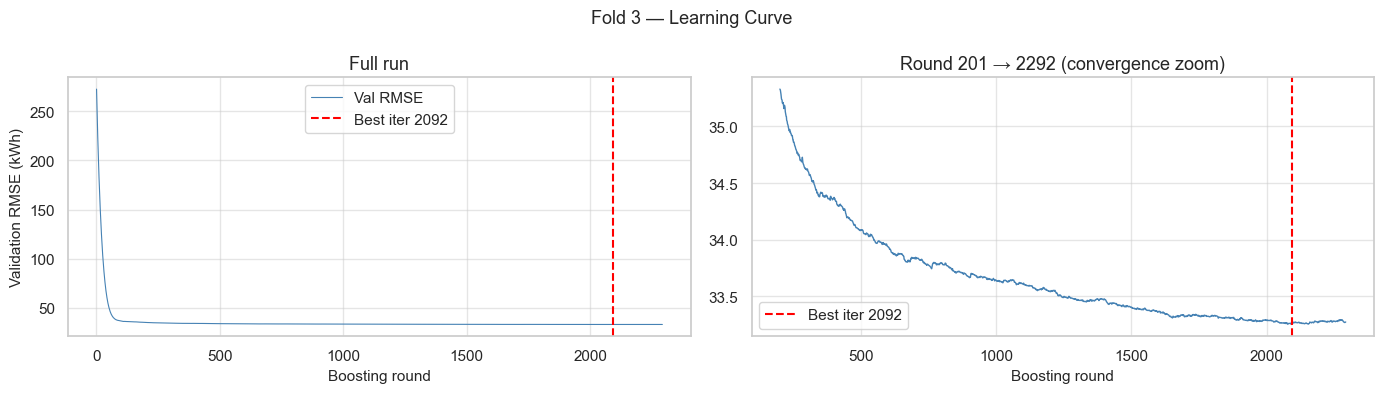

  Best iter 2092  |  Best val RMSE 33.2517  |  Final val RMSE 33.2736
🏃 View run stage8_full_pipeline at: http://localhost:5000/#/experiments/3/runs/5363150c953c4c6b9d201dcfee5e4823
🧪 View experiment at: http://localhost:5000/#/experiments/3


,fold,val_rmse,val_mae,best_iteration,train_s
0,1,21.921497,6.505953,1492,343.590774
1,2,26.832046,6.954657,3024,698.810411
2,3,33.249207,7.509111,2092,582.339864


In [27]:
tuning_rows = []
with mlflow.start_run(run_name='stage8_full_pipeline'):
    mlflow.log_params(BASE_LGB_PARAMS)
    mlflow.log_params({'n_features': len(FEATURE_COLS)})

    for fold in FOLDS:
        tr, va = split_by_dates(selected_dataset, fold['train_start'], fold['train_end'], fold['val_start'], fold['val_end'])
        t0 = time.time()
        model, metrics = train_eval_lgbm(tr, va, BASE_LGB_PARAMS)
        elapsed = time.time() - t0

        with mlflow.start_run(run_name=f'fold_{fold["fold"]}', nested=True):
            mlflow.log_metrics({'val_rmse': metrics['rmse'], 'val_mae': metrics['mae'],
                                'best_iteration': metrics['best_iteration'], 'train_s': elapsed})

        tuning_rows.append({
            'fold': fold['fold'], 'val_rmse': metrics['rmse'],
            'val_mae': metrics['mae'], 'best_iteration': metrics['best_iteration'], 'train_s': elapsed,
        })
        print(f"\nFold {fold['fold']}  RMSE={metrics['rmse']:.3f}  MAE={metrics['mae']:.3f}  best_iter={metrics['best_iteration']}  time={elapsed:.0f}s")
        plot_fold_learning_curve(model, fold['fold'])
        del tr, va
        gc.collect()

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

## Section 7 — Refit & Evaluate on Test Period

In [28]:
fit_df  = selected_dataset[selected_dataset['timestamp'] < TEST_START].copy()
test_df = selected_dataset[selected_dataset['timestamp'] >= TEST_START].copy()

final_train = fit_df[fit_df['timestamp'] <= pd.Timestamp('2017-07-31 23:00:00')].copy()
final_valid = fit_df[
    (fit_df['timestamp'] >= pd.Timestamp('2017-08-01')) &
    (fit_df['timestamp'] <= pd.Timestamp('2017-09-30 23:00:00'))
].copy()

early_stop_model = lgb.LGBMRegressor(**BASE_LGB_PARAMS)
early_stop_model.fit(
    final_train[FEATURE_COLS], final_train[TARGET_COL],
    eval_set=[(final_valid[FEATURE_COLS], final_valid[TARGET_COL])],
    eval_metric='rmse',
    categorical_feature=CAT_PRESENT,
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS, first_metric_only=True, verbose=True),
        lgb.log_evaluation(250),
    ],
)

selected_iteration = early_stop_model.best_iteration_ or BASE_LGB_PARAMS['n_estimators']
print(f'Selected iteration: {selected_iteration}')

Training until validation scores don't improve for 200 rounds
[250]	valid_0's rmse: 34.0934
[500]	valid_0's rmse: 33.8518
[750]	valid_0's rmse: 33.6773
[1000]	valid_0's rmse: 33.6019
[1250]	valid_0's rmse: 33.4211
[1500]	valid_0's rmse: 33.2662
[1750]	valid_0's rmse: 33.1779
[2000]	valid_0's rmse: 33.1695
[2250]	valid_0's rmse: 33.1242
Early stopping, best iteration is:
[2162]	valid_0's rmse: 33.0693
Evaluated only: rmse
Selected iteration: 2162


In [29]:
production_params = {**BASE_LGB_PARAMS, 'n_estimators': selected_iteration}
final_model = lgb.LGBMRegressor(**production_params)
final_model.fit(fit_df[FEATURE_COLS], fit_df[TARGET_COL], categorical_feature=CAT_PRESENT)

test_pred = final_model.predict(test_df[FEATURE_COLS]).clip(min=0)
test_rmse = rmse(test_df[TARGET_COL], test_pred)
test_mae  = mean_absolute_error(test_df[TARGET_COL], test_pred)

print('=== Stage 8 Test Results ===')
print(f'Test RMSE      : {test_rmse:.3f} kWh')
print(f'Test MAE       : {test_mae:.3f} kWh')
print(f'Selected trees : {selected_iteration}')
print()
print('=== Baselines ===')
print('Stage 4b  RMSE: 17.732 kWh   MAE: 5.914 kWh')
print('Stage 7   RMSE: 17.886 kWh   MAE: 5.923 kWh')

final_model.booster_.save_model(str(STAGE8_MODEL_OUT))
print(f'\nModel saved \u2192 {STAGE8_MODEL_OUT}')

=== Stage 8 Test Results ===
Test RMSE      : 24.981 kWh
Test MAE       : 6.574 kWh
Selected trees : 2162

=== Baselines ===
Stage 4b  RMSE: 17.732 kWh   MAE: 5.914 kWh
Stage 7   RMSE: 17.886 kWh   MAE: 5.923 kWh

Model saved → ..\..\data\processed\anomaly-detection\stage8_lgbm_model.txt


## Section 8 — Diagnostics: Feature Importance

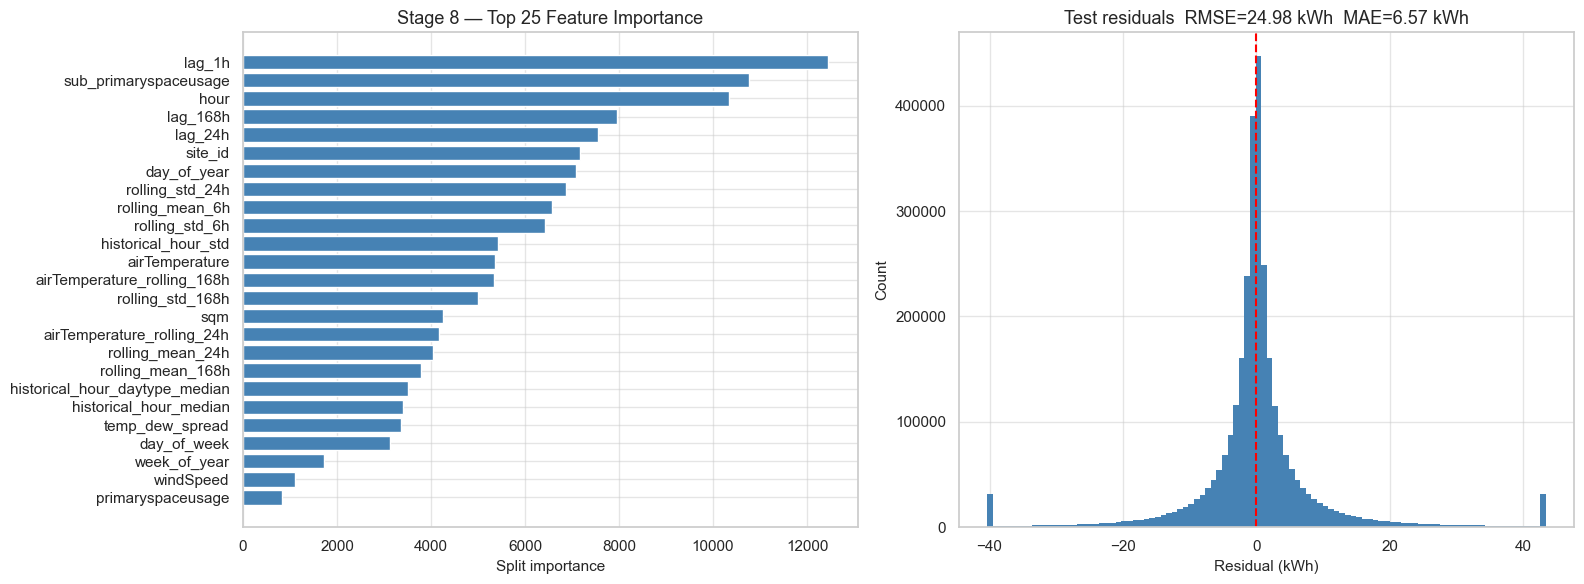

,feature,importance
0,lag_1h,12455
1,sub_primaryspaceusage,10768
2,hour,10345
3,lag_168h,7960
4,lag_24h,7543
5,site_id,7177
6,day_of_year,7084
7,rolling_std_24h,6862
8,rolling_mean_6h,6576
9,rolling_std_6h,6433


In [30]:
importance = (
    pd.DataFrame({'feature': final_model.feature_name_, 'importance': final_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

resid_test = test_df[TARGET_COL].values - test_pred
lo, hi = np.percentile(resid_test, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top25 = importance.head(25)
axes[0].barh(top25['feature'][::-1], top25['importance'][::-1], color='steelblue')
axes[0].set_title('Stage 8 \u2014 Top 25 Feature Importance')
axes[0].set_xlabel('Split importance')

axes[1].hist(np.clip(resid_test, lo, hi), bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Test residuals  RMSE={test_rmse:.2f} kWh  MAE={test_mae:.2f} kWh')
axes[1].set_xlabel('Residual (kWh)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
display(importance.head(35))

## Section 9 — Residual Calibration & Anomaly Scoring on Test Period

In [31]:
cal_pred  = early_stop_model.predict(final_valid[FEATURE_COLS]).clip(min=0)
cal_resid = pd.DataFrame({
    'building_id': final_valid['building_id'].values,
    'resid':       final_valid[TARGET_COL].values - cal_pred,
})

resid_stats = (
    cal_resid.groupby('building_id')['resid']
    .agg(
        resid_median='median',
        resid_mad=lambda x: np.median(np.abs(x - np.median(x))),
    )
    .reset_index()
)

bld_meta = (
    test_df[['building_id', 'site_id', 'primaryspaceusage', 'sub_primaryspaceusage']]
    .drop_duplicates('building_id')
    .assign(
        primaryspaceusage=lambda d: d['primaryspaceusage'].astype(str),
        sub_primaryspaceusage=lambda d: d['sub_primaryspaceusage'].astype(str),
    )
)
resid_stats = bld_meta.merge(resid_stats, on='building_id', how='left')

nan_mask = resid_stats['resid_median'].isna()

group_fb_sub = (
    resid_stats.loc[~nan_mask]
    .groupby('sub_primaryspaceusage')[['resid_median', 'resid_mad']]
    .median()
    .rename(columns={'resid_median': 'fb_median_sub', 'resid_mad': 'fb_mad_sub'})
)
group_fb_psu = (
    resid_stats.loc[~nan_mask]
    .groupby('primaryspaceusage')[['resid_median', 'resid_mad']]
    .median()
    .rename(columns={'resid_median': 'fb_median_psu', 'resid_mad': 'fb_mad_psu'})
)

resid_stats = resid_stats.merge(group_fb_sub, on='sub_primaryspaceusage', how='left')
resid_stats = resid_stats.merge(group_fb_psu, on='primaryspaceusage', how='left')

resid_stats.loc[nan_mask, 'resid_median'] = resid_stats.loc[nan_mask, 'fb_median_sub'].fillna(
    resid_stats.loc[nan_mask, 'fb_median_psu']
)
resid_stats.loc[nan_mask, 'resid_mad'] = resid_stats.loc[nan_mask, 'fb_mad_sub'].fillna(
    resid_stats.loc[nan_mask, 'fb_mad_psu']
)
resid_stats = resid_stats.drop(columns=['fb_median_sub', 'fb_mad_sub', 'fb_median_psu', 'fb_mad_psu'])

print(f'Buildings calibrated (direct): {int((~nan_mask).sum()):,}')
print(f'Buildings on group fallback  : {int(nan_mask.sum())}')

resid_stats.to_parquet(STAGE8_RESID_STATS_OUT, index=False)
resid_stats_model = resid_stats.drop(columns=['site_id', 'primaryspaceusage', 'sub_primaryspaceusage'])

Buildings calibrated (direct): 1,421
Buildings on group fallback  : 35


In [32]:
score_df = test_df.copy()
score_df['predicted'] = test_pred
score_df['residual']  = score_df[TARGET_COL].values - score_df['predicted'].values

score_df = score_df.merge(resid_stats_model, on='building_id', how='left')

MAD_SCALE = 1.4826
MAD_FLOOR = 1e-3
safe_mad = (score_df['resid_mad'] * MAD_SCALE).clip(lower=MAD_FLOOR)
score_df['residual_z']    = (score_df['residual'] - score_df['resid_median']) / safe_mad
score_df['anomaly_score'] = score_df['residual_z'].abs()
score_df['is_anomaly']    = score_df['anomaly_score'] > ANOMALY_Z
score_df['direction'] = np.where(
    score_df['residual_z'] >  ANOMALY_Z, 'over',
    np.where(score_df['residual_z'] < -ANOMALY_Z, 'under', 'normal'),
)

SEV_THRESHOLDS = [(10.0, 'Critical'), (6.0, 'High'), (4.0, 'Medium'), (3.0, 'Low')]
score_df['severity'] = np.select(
    [score_df['anomaly_score'] >= t for t, _ in SEV_THRESHOLDS],
    [s for _, s in SEV_THRESHOLDS],
    default='normal',
)

n_total   = len(score_df)
n_anomaly = int(score_df['is_anomaly'].sum())
print(f'Scoring rows       : {n_total:,}')
print(f'Anomalies flagged  : {n_anomaly:,}  ({n_anomaly / n_total:.2%})')
print(f'  Over-consumption : {int((score_df["direction"] == "over").sum()):,}')
print(f'  Under-consumption: {int((score_df["direction"] == "under").sum()):,}')

sev_order = ['Critical', 'High', 'Medium', 'Low']
sev_counts = (
    score_df[score_df['is_anomaly']]['severity']
    .value_counts().reindex(sev_order).fillna(0).astype(int)
)
print('\nSeverity breakdown:')
for sev, cnt in sev_counts.items():
    print(f'  {sev:8s}: {cnt:,}  ({cnt / max(n_anomaly, 1):.1%})')

top20 = (
    score_df[score_df['is_anomaly']].groupby('building_id').size()
    .sort_values(ascending=False).head(20)
    .rename('anomaly_count')
)
print('\nTop 20 buildings by anomaly count:')
display(top20.to_frame())

Scoring rows       : 3,067,082
Anomalies flagged  : 188,813  (6.16%)
  Over-consumption : 100,167
  Under-consumption: 88,646

Severity breakdown:
  Critical: 15,287  (8.1%)
  High    : 29,258  (15.5%)
  Medium  : 60,345  (32.0%)
  Low     : 83,923  (44.4%)

Top 20 buildings by anomaly count:


,anomaly_count
building_id,
Cockatoo_assembly_Valencia,1174
Fox_office_Demetrius,1144
Gator_assembly_Maurine,1058
Moose_education_Maria,953
Lamb_office_Bertha,945
Rat_public_Kelle,894
Gator_assembly_Kayleigh,812
Lamb_industrial_Carla,778
Hog_parking_Jean,770


## Section 10 — Export

In [33]:
keep_cols = ['building_id', 'timestamp', TARGET_COL, 'predicted', 'residual',
             'residual_z', 'anomaly_score', 'severity', 'direction', 'is_anomaly']
for extra in ['site_id', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm']:
    if extra in score_df.columns:
        keep_cols.append(extra)

out_df = score_df[keep_cols].copy()
out_df.to_parquet(STAGE8_ANOMALIES_OUT, index=False)

print(f'Exported \u2192 {STAGE8_ANOMALIES_OUT}')
print(f'Rows     : {len(out_df):,}')
print(f'Anomalies: {out_df["is_anomaly"].sum():,}  ({out_df["is_anomaly"].mean():.2%})')

Exported → ..\..\data\processed\anomaly-detection\stage8_anomalies.parquet
Rows     : 3,067,082
Anomalies: 188,813  (6.16%)
